## Installation of scikit-learn

In [2]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 7.5 MB/s eta 0:00:01
   ------- -------------------------------- 1.6/8.3 MB 4.8 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 4.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 4.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 4.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.8 MB/s  0:00:02

   ----------------

In [3]:
import sklearn
print(sklearn.__version__)

1.9.0


## Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 5)

## Installation of liabraries

In [6]:
pip install statsmodels prophet scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Data Loading

In [8]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\SATYA\OneDrive\Desktop\Week3-Work-Demand-Forecasting
['.idea', '.ipynb_checkpoints', 'demand_forecasting.ipynb', 'final_anomaly_dataset.csv', 'final_anomaly_results.csv']


## Building and debugging a forecasting pipeline

In [9]:
import pandas as pd

df = pd.read_csv(
    "final_anomaly_results.csv",
    parse_dates=["OrderDate"]
)

df = df.sort_values(
    ["CategoryName", "OrderDate"]
).reset_index(drop=True)

df.head()

,OrderDate,CategoryName,Quantity,ZScore,ZScore_Anomaly,IQR_Lower,IQR_Upper,IQR_Anomaly,IF_Anomaly,Anomaly_Method_Count,Final_Anomaly
0,2013-06-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
1,2013-07-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
2,2013-08-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
3,2013-09-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
4,2013-10-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False


<Axes: title={'center': 'CPU Monthly Demand'}, xlabel='OrderDate'>

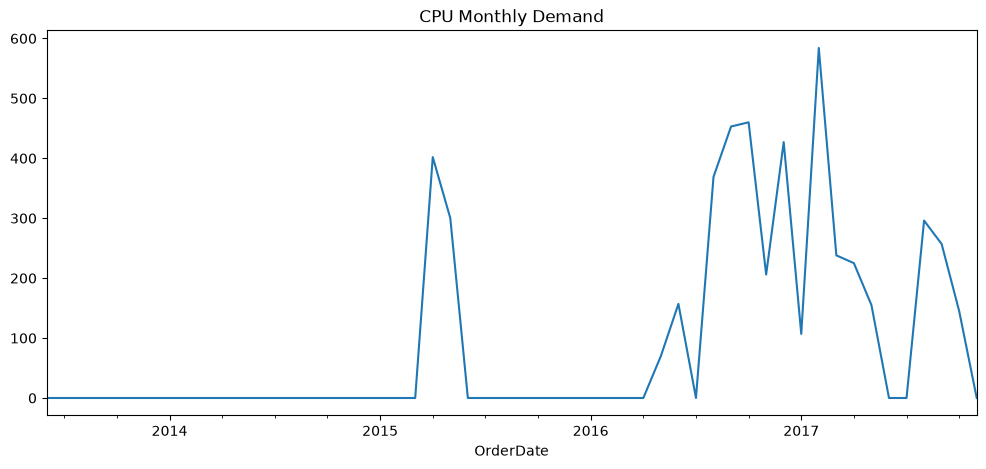

In [10]:
category = "CPU"
series = df[df["CategoryName"] == category].set_index("OrderDate")["Quantity"]
series = series.asfreq("MS")  # MS = Month Start, ensures a continuous monthly index
series.plot(title=f"{category} Monthly Demand")

In [12]:
print("Missing months after asfreq:", series.isna().sum())
series = series.ffill()  # only if any exist

Missing months after asfreq: 0


## Chronological train/test split

In [13]:
test_months = 6  # hold out the last 6 months as "unseen" test data
train = series.iloc[:-test_months]
test = series.iloc[-test_months:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} months)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} months)")

Train: 2013-06-01 00:00:00 to 2017-05-01 00:00:00 (48 months)
Test:  2017-06-01 00:00:00 to 2017-11-01 00:00:00 (6 months)
